# CAVS: Eco-Cruise (IDM)

This Connected Automated Vehicle (CAV) demo uses the Intelligent Driver
Model (IDM) to adjust the vehicle's speed profile toward a desired target
speed.

In [1]:
import os

import seaborn as sns

import sys
from pathlib import Path

import fastsim as fsim
from plot_utils import plot_speed_by_time, plot_speed_by_dist

In [2]:
sns.set_theme()

SHOW_PLOTS = os.environ.get("SHOW_PLOTS", "true").lower() == "true"
SAVE_FIGS = os.environ.get("SAVE_FIGS", "false").lower() == "true"

## Setup

In [3]:
veh = fsim.Vehicle.from_resource("2012_Ford_Fusion.yaml")
veh.set_save_interval(1)

cyc = fsim.Cycle.from_resource("udds.csv")
end_idle_duration_s = cyc.ending_idle_time_s()
cyc0 = cyc.copy()
cyc = cyc.extend_time(absolute_time_s=240.0, time_fraction=0.3)

vavg = cyc0.average_speed_m_per_s(while_moving=True)

## Configure IDM Parameters

IDM parameters:
- `idm_desired_speed`: desired speed (here set to the cycle's moving average)
- `idm_headway`: headway time desired to vehicle in front
- `idm_minimum_gap`: minimum desired gap between vehicle and lead vehicle
- `idm_delta`: IDM delta parameter
- `idm_acceleration` / `idm_deceleration`: IDM acceleration and deceleration parameters

In [4]:
man = fsim.Maneuver.create_from(cyc, veh.copy())
d = man.to_pydict()
d["idm_allow"] = True
d["idm_desired_speed_meters_per_second"] = vavg
d["idm_headway_seconds"] = 1.0
d["idm_minimum_gap_meters"] = 1.0
d["idm_delta"] = 4.0
d["idm_acceleration_meters_per_second_squared"] = 1.0
d["idm_deceleration_meters_per_second_squared"] = 2.5
man = fsim.Maneuver.from_pydict(d)

cyc = man.apply_maneuvers()
cyc = cyc.trim_ending_idle(idle_to_keep_s=end_idle_duration_s)

In [5]:
sd = fsim.SimDrive(veh, cyc)
sd.walk()

## Results

Original cycle speed vs. achieved speed with IDM eco-cruise applied.

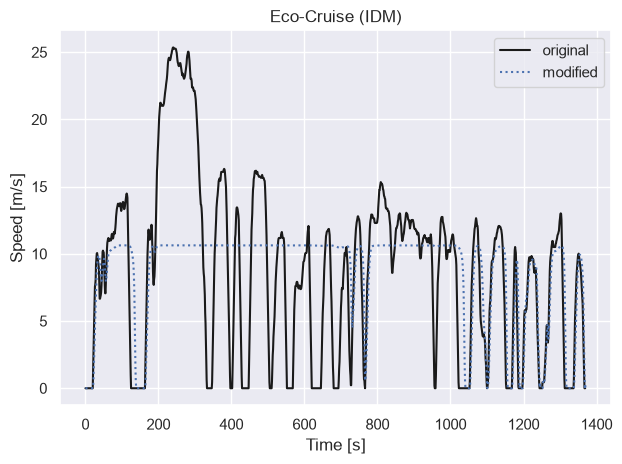

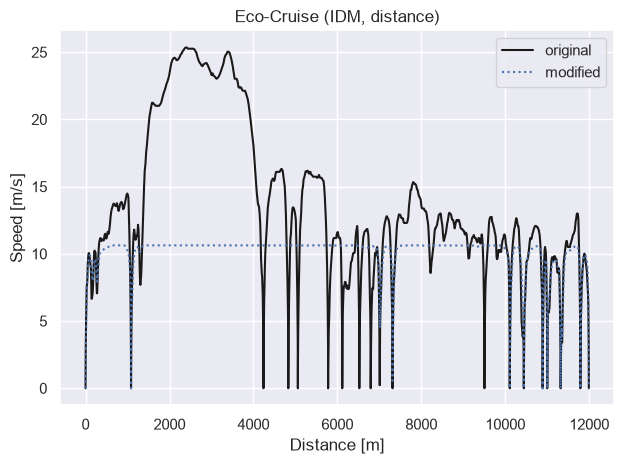

In [6]:
if SHOW_PLOTS:
    c0 = cyc0.to_pydict()
    df = sd.to_dataframe(backend='polars')
    plot_speed_by_time(df, c0, title="Eco-Cruise (IDM)",
                       save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)
    plot_speed_by_dist(df, c0, title="Eco-Cruise (IDM, distance)",
                       save_figs=SAVE_FIGS, show_plots=SHOW_PLOTS)